In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("/Users/shreedharkokate/Desktop/business-anomaly-agent/data/shree_market.csv")

In [3]:
df.head()

,date,traffic,orders,revenue,marketing_cost,refunds,Conversion rate
0,2026-01-01,18596,412,1068666,44323,22,2.215530
1,2026-01-02,17834,426,1010227,35692,27,2.388696
2,2026-01-03,18777,386,902995,43489,19,2.055706
3,2026-01-04,19827,423,1088112,40030,22,2.133454
4,2026-01-05,17719,375,924930,37055,23,2.116372


In [4]:
df.shape

(90, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             90 non-null     object 
 1   traffic          90 non-null     int64  
 2   orders           90 non-null     int64  
 3   revenue          90 non-null     int64  
 4   marketing_cost   90 non-null     int64  
 5   refunds          90 non-null     int64  
 6   Conversion rate  90 non-null     float64
dtypes: float64(1), int64(5), object(1)
memory usage: 5.1+ KB


In [6]:
df.describe()

,traffic,orders,revenue,marketing_cost,refunds,Conversion rate
count,90.000000,90.000000,9.000000e+01,90.000000,90.000000,90.000000
mean,18115.566667,394.677778,9.765385e+05,40181.977778,20.744444,2.196992
std,2586.305990,40.678191,1.582812e+05,2438.640651,9.947685,0.235575
min,14856.000000,310.000000,4.500000e+04,34143.000000,9.000000,0.890000
25%,17277.500000,364.000000,8.937298e+05,38310.750000,16.000000,2.053897
50%,17847.500000,401.000000,9.849275e+05,40136.000000,20.000000,2.214604
75%,18610.250000,427.500000,1.067080e+06,41881.750000,23.750000,2.308903
max,40000.000000,510.000000,1.285001e+06,46399.000000,100.000000,2.739726


In [7]:
df["date"].max()

'2026-03-31'

In [8]:
df["date"].min()

'2026-01-01'

In [9]:
df["date"].isnull().sum()

np.int64(0)

In [10]:
df["date"].duplicated().sum()

np.int64(0)

In [11]:
df["date"].is_monotonic_increasing

True

In [12]:
df["traffic"].max()

40000

In [13]:
df.iloc[df["traffic"].idxmax()] # idxmax :returns the index label of the first occurrence of the maximum 
#value along a specified axis

date               2026-02-10
traffic                 40000
orders                    356
revenue               1013602
marketing_cost          39346
refunds                    12
Conversion rate          0.89
Name: 40, dtype: object

In [14]:
df["orders"].max()

510

In [15]:
df.iloc[df["orders"].idxmax()]

date               2026-03-31
traffic                 18615
orders                    510
revenue               1285001
marketing_cost          37518
refunds                    14
Conversion rate      2.739726
Name: 89, dtype: object

In [16]:
col = df.columns.drop("date")

In [17]:
col

Index(['traffic', 'orders', 'revenue', 'marketing_cost', 'refunds',
       'Conversion rate'],
      dtype='object')

In [18]:
df[col].mean()

traffic             18115.566667
orders                394.677778
revenue            976538.522222
marketing_cost      40181.977778
refunds                20.744444
Conversion rate         2.196992
dtype: float64

In [19]:
df[col].max()

traffic            4.000000e+04
orders             5.100000e+02
revenue            1.285001e+06
marketing_cost     4.639900e+04
refunds            1.000000e+02
Conversion rate    2.739726e+00
dtype: float64

In [20]:
df[col].min()

traffic            14856.00
orders               310.00
revenue            45000.00
marketing_cost     34143.00
refunds                9.00
Conversion rate        0.89
dtype: float64

In [21]:
df[col].std()

traffic              2586.305990
orders                 40.678191
revenue            158281.175408
marketing_cost       2438.640651
refunds                 9.947685
Conversion rate         0.235575
dtype: float64

In [22]:
z_for_refund = (df["refunds"].max() - df["refunds"].mean())/df["refunds"].std()

In [23]:
z_for_refund

np.float64(7.967236449219674)

In [24]:
z_for_order = (df["orders"].max() - df["orders"].mean())/df["orders"].std()

In [25]:
z_for_order

np.float64(2.8349889488923035)

In [26]:
z_for_revenue = (df["revenue"].max() - df["revenue"].mean())/df["revenue"].std()

In [27]:
z_for_revenue

np.float64(1.94882604948199)

In [28]:
z_for_marketing_cost= (df["marketing_cost"].max() - df["marketing_cost"].mean())/df["marketing_cost"].std()

In [29]:
z_for_marketing_cost

np.float64(2.5493802130826273)

In [30]:
z_for_Conversion_rate= (df["Conversion rate"].max() - df["Conversion rate"].mean())/df["Conversion rate"].std()

In [31]:
z_for_Conversion_rate

np.float64(2.3038728309171455)

In [32]:
"""FOR DAY ROLLING WINDOW"""

'FOR DAY ROLLING WINDOW'

In [33]:
df["traffic"].rolling(7).mean()

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
          ...     
85    17622.142857
86    18119.857143
87    18213.857143
88    18061.857143
89    17896.428571
Name: traffic, Length: 90, dtype: float64

In [34]:
mean_rolling =df["traffic"].rolling(7).mean().shift(1)
print(mean_rolling.to_string())

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
6              NaN
7     18623.857143
8     18670.142857
9     18613.285714
10    18595.285714
11    18254.714286
12    18215.000000
13    18296.571429
14    17697.857143
15    17270.714286
16    17254.857143
17    16988.142857
18    17121.571429
19    17045.714286
20    16762.142857
21    17341.285714
22    17598.285714
23    17706.285714
24    17635.714286
25    17488.428571
26    17663.142857
27    17707.857143
28    17521.000000
29    17456.714286
30    17395.000000
31    17536.000000
32    17946.857143
33    17925.428571
34    17941.428571
35    18018.142857
36    17911.714286
37    17997.571429
38    17764.857143
39    17219.714286
40    17255.857143
41    20580.142857
42    20468.428571
43    20658.000000
44    20570.571429
45    20653.000000
46    20757.285714
47    20644.571429
48    17682.857143
49    17712.428571
50    17430.000000
51    17537.142857
52    17724.

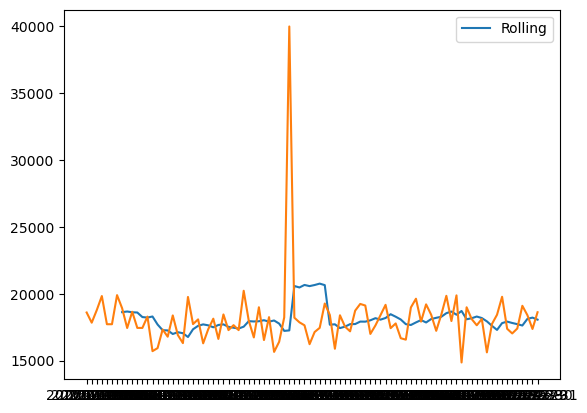

In [35]:
plt.plot(df["date"] , df["traffic"].rolling(7).mean().shift(1), label="Rolling")
plt.plot(df["date"] , df["traffic"])
plt.legend()

In [36]:
df.columns

Index(['date', 'traffic', 'orders', 'revenue', 'marketing_cost', 'refunds',
       'Conversion rate'],
      dtype='object')

In [37]:
df["date"] =pd.to_datetime(df["date"])
df.set_index("date", inplace = True)

In [38]:
standard_dev_ROLLING = df["traffic"].rolling(7).std().shift(1)

In [39]:
print(standard_dev_ROLLING.to_string())


date
2026-01-01            NaN
2026-01-02            NaN
2026-01-03            NaN
2026-01-04            NaN
2026-01-05            NaN
2026-01-06            NaN
2026-01-07            NaN
2026-01-08     944.192147
2026-01-09     950.519232
2026-01-10    1018.353690
2026-01-11    1016.088696
2026-01-12     930.352749
2026-01-13     962.413459
2026-01-14     937.236160
2026-01-15    1074.531747
2026-01-16    1101.683517
2026-01-17    1099.705025
2026-01-18     915.663954
2026-01-19    1051.035181
2026-01-20    1043.271891
2026-01-21     909.946780
2026-01-22    1321.341959
2026-01-23    1167.041804
2026-01-24    1172.504401
2026-01-25    1249.599364
2026-01-26    1207.723045
2026-01-27    1198.525960
2026-01-28    1144.010698
2026-01-29     811.977422
2026-01-30     810.577513
2026-01-31     770.583761
2026-02-01     607.800406
2026-02-02    1169.999919
2026-02-03    1167.393230
2026-02-04    1147.078152
2026-02-05    1203.336255
2026-02-06    1307.998944
2026-02-07    1307.605044
2026-02

In [40]:
Z_value_for_each_traffic = (df["traffic"] - df["traffic"].rolling(7).mean())/standard_dev_ROLLING 

In [41]:
print(Z_value_for_each_traffic.to_string())

date
2026-01-01          NaN
2026-01-02          NaN
2026-01-03          NaN
2026-01-04          NaN
2026-01-05          NaN
2026-01-06          NaN
2026-01-07          NaN
2026-01-08     0.264625
2026-01-09    -1.238571
2026-01-10     0.054710
2026-01-11    -0.798862
2026-01-12    -0.831943
2026-01-13    -0.006828
2026-01-14    -2.127380
2026-01-15    -1.247720
2026-01-16     0.063669
2026-01-17    -0.185634
2026-01-18     1.371058
2026-01-19    -0.129124
2026-01-20    -0.438182
2026-01-21     2.655885
2026-01-22     0.098925
2026-01-23     0.321080
2026-01-24    -1.147726
2026-01-25    -0.113979
2026-01-26     0.389044
2026-01-27    -0.909331
2026-01-28     0.812055
2026-01-29    -0.218866
2026-01-30     0.313357
2026-01-31    -0.336109
2026-02-01     3.743240
2026-02-02     0.049206
2026-02-03    -1.037721
2026-02-04     0.844630
2026-02-05    -1.144912
2026-02-06     0.192988
2026-02-07    -1.618881
2026-02-08    -0.516689
2026-02-09     0.818215
2026-02-10    15.811580
2026-02-11 

In [42]:
sd_rolling_order = df["orders"].rolling(7).std().shift(1)

In [43]:
print(sd_rolling_order.to_string())

date
2026-01-01          NaN
2026-01-02          NaN
2026-01-03          NaN
2026-01-04          NaN
2026-01-05          NaN
2026-01-06          NaN
2026-01-07          NaN
2026-01-08    37.706890
2026-01-09    38.735981
2026-01-10    37.907783
2026-01-11    37.605091
2026-01-12    42.871347
2026-01-13    43.196671
2026-01-14    37.554405
2026-01-15    37.143223
2026-01-16    30.468563
2026-01-17    32.076545
2026-01-18    39.257392
2026-01-19    38.418745
2026-01-20    38.117612
2026-01-21    39.074410
2026-01-22    31.826165
2026-01-23    27.251038
2026-01-24    27.449521
2026-01-25    29.057414
2026-01-26    28.097619
2026-01-27    29.371188
2026-01-28    27.996598
2026-01-29    27.262393
2026-01-30    29.234683
2026-01-31    30.113278
2026-02-01    24.938018
2026-02-02    23.978165
2026-02-03    30.190664
2026-02-04    41.624169
2026-02-05    41.092231
2026-02-06    42.353389
2026-02-07    45.539099
2026-02-08    53.916161
2026-02-09    54.245474
2026-02-10    47.249087
2026-02-11 

In [44]:
mean_rolling_order = df["orders"].rolling(7).mean().shift(1)

In [45]:
print(mean_rolling_order.to_string())

date
2026-01-01           NaN
2026-01-02           NaN
2026-01-03           NaN
2026-01-04           NaN
2026-01-05           NaN
2026-01-06           NaN
2026-01-07           NaN
2026-01-08    401.142857
2026-01-09    403.142857
2026-01-10    397.000000
2026-01-11    399.142857
2026-01-12    386.428571
2026-01-13    385.571429
2026-01-14    393.000000
2026-01-15    374.571429
2026-01-16    363.000000
2026-01-17    364.714286
2026-01-18    369.142857
2026-01-19    380.000000
2026-01-20    381.571429
2026-01-21    376.857143
2026-01-22    382.285714
2026-01-23    388.571429
2026-01-24    389.142857
2026-01-25    390.000000
2026-01-26    384.857143
2026-01-27    389.000000
2026-01-28    390.142857
2026-01-29    390.714286
2026-01-30    395.000000
2026-01-31    397.142857
2026-02-01    392.714286
2026-02-02    397.571429
2026-02-03    402.857143
2026-02-04    396.714286
2026-02-05    407.714286
2026-02-06    410.142857
2026-02-07    403.142857
2026-02-08    391.571429
2026-02-09    385.28

In [46]:
df[df["refunds"]==100]

,traffic,orders,revenue,marketing_cost,refunds,Conversion rate
date,,,,,,
2026-03-17,18986,433,1051048,40696,100,2.280628


In [47]:
df.describe()

,traffic,orders,revenue,marketing_cost,refunds,Conversion rate
count,90.000000,90.000000,9.000000e+01,90.000000,90.000000,90.000000
mean,18115.566667,394.677778,9.765385e+05,40181.977778,20.744444,2.196992
std,2586.305990,40.678191,1.582812e+05,2438.640651,9.947685,0.235575
min,14856.000000,310.000000,4.500000e+04,34143.000000,9.000000,0.890000
25%,17277.500000,364.000000,8.937298e+05,38310.750000,16.000000,2.053897
50%,17847.500000,401.000000,9.849275e+05,40136.000000,20.000000,2.214604
75%,18610.250000,427.500000,1.067080e+06,41881.750000,23.750000,2.308903
max,40000.000000,510.000000,1.285001e+06,46399.000000,100.000000,2.739726


In [48]:
df.columns

Index(['traffic', 'orders', 'revenue', 'marketing_cost', 'refunds',
       'Conversion rate'],
      dtype='object')

In [49]:
z_score = pd.DataFrame()

In [50]:
mean_rolling = pd.DataFrame()

In [51]:
for a in df.columns :
    mean_rolling[a] = df[a].rolling(7).mean().shift(1)
    
    

In [52]:
mean_rolling 

,traffic,orders,revenue,marketing_cost,refunds,Conversion rate
date,,,,,,
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-04,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-05,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2026-03-27,17724.000000,378.571429,907171.142857,40656.428571,15.857143,2.135202
2026-03-28,17622.142857,381.714286,900339.428571,40534.714286,17.571429,2.165844
2026-03-29,18119.857143,396.142857,945807.285714,40618.285714,17.857143,2.188150


In [53]:
for a in df.columns :
    mean = df[a].rolling(7).mean().shift(1)
    std = df[a].rolling(7).std().shift(1)
    z=(df[a]-mean)/std
    z_score[a] = z
    

In [54]:
print(z_score.to_string())

              traffic    orders   revenue  marketing_cost    refunds  Conversion rate
date                                                                                 
2026-01-01        NaN       NaN       NaN             NaN        NaN              NaN
2026-01-02        NaN       NaN       NaN             NaN        NaN              NaN
2026-01-03        NaN       NaN       NaN             NaN        NaN              NaN
2026-01-04        NaN       NaN       NaN             NaN        NaN              NaN
2026-01-05        NaN       NaN       NaN             NaN        NaN              NaN
2026-01-06        NaN       NaN       NaN             NaN        NaN              NaN
2026-01-07        NaN       NaN       NaN             NaN        NaN              NaN
2026-01-08   0.313647  0.659220  0.537023       -0.689017  -0.498117         0.637591
2026-01-09  -1.298388 -0.520004 -0.902102        0.267231  -0.401823         0.245338
2026-01-10   0.037035  0.105519 -0.700484       -0.618

In [55]:
anomalies = z_score.abs()>3

In [56]:
anomalies.head(15)

,traffic,orders,revenue,marketing_cost,refunds,Conversion rate
date,,,,,,
2026-01-01,False,False,False,False,False,False
2026-01-02,False,False,False,False,False,False
2026-01-03,False,False,False,False,False,False
2026-01-04,False,False,False,False,False,False
2026-01-05,False,False,False,False,False,False
2026-01-06,False,False,False,False,False,False
2026-01-07,False,False,False,False,False,False
2026-01-08,False,False,False,False,False,False
2026-01-09,False,False,False,False,False,False


 anomaly = anomalies.any(Axis=1)

In [57]:
 anomaly = anomalies.any(axis=1)

In [58]:
anomaly

date
2026-01-01    False
2026-01-02    False
2026-01-03    False
2026-01-04    False
2026-01-05    False
              ...  
2026-03-27    False
2026-03-28     True
2026-03-29    False
2026-03-30    False
2026-03-31     True
Length: 90, dtype: bool

In [59]:
anomaly_dates = anomaly[anomaly].index #Filters the Series to keep only rows where the value is True

In [60]:
databse_anomalies= anomalies.loc[anomaly_dates]

In [61]:
databse_anomalies

,traffic,orders,revenue,marketing_cost,refunds,Conversion rate
date,,,,,,
2026-01-13,False,False,False,True,True,False
2026-01-17,False,False,False,False,False,True
2026-01-21,True,False,False,False,False,False
2026-01-28,False,False,False,False,True,False
2026-02-01,True,False,False,False,False,False
2026-02-10,True,False,False,False,False,True
2026-02-15,False,False,True,False,False,False
2026-02-23,False,False,False,True,False,False
2026-03-02,False,False,True,False,False,False


In [62]:
databse_anomalies.loc["2026-01-13"].index[databse_anomalies.loc["2026-01-13"]== True]
#.loc = location ,  index for column names

Index(['marketing_cost', 'refunds'], dtype='object')

In [63]:
list_final_anomaly=[]

In [64]:
for date in databse_anomalies.index :
    list_final_anomaly.append([date,databse_anomalies.loc[date].index[databse_anomalies.loc[date]== True]])

In [65]:
list_final_anomaly

[[Timestamp('2026-01-13 00:00:00'),
  Index(['marketing_cost', 'refunds'], dtype='object')],
 [Timestamp('2026-01-17 00:00:00'),
  Index(['Conversion rate'], dtype='object')],
 [Timestamp('2026-01-21 00:00:00'), Index(['traffic'], dtype='object')],
 [Timestamp('2026-01-28 00:00:00'), Index(['refunds'], dtype='object')],
 [Timestamp('2026-02-01 00:00:00'), Index(['traffic'], dtype='object')],
 [Timestamp('2026-02-10 00:00:00'),
  Index(['traffic', 'Conversion rate'], dtype='object')],
 [Timestamp('2026-02-15 00:00:00'), Index(['revenue'], dtype='object')],
 [Timestamp('2026-02-23 00:00:00'), Index(['marketing_cost'], dtype='object')],
 [Timestamp('2026-03-02 00:00:00'), Index(['revenue'], dtype='object')],
 [Timestamp('2026-03-08 00:00:00'),
  Index(['Conversion rate'], dtype='object')],
 [Timestamp('2026-03-12 00:00:00'), Index(['revenue'], dtype='object')],
 [Timestamp('2026-03-16 00:00:00'), Index(['traffic'], dtype='object')],
 [Timestamp('2026-03-17 00:00:00'), Index(['refunds'], d

In [66]:
final_dataframe = pd.DataFrame(list_final_anomaly)

In [67]:
final_dataframe.columns= ["date" , "Anomaly"]

In [68]:
final_dataframe

,date,Anomaly
0,2026-01-13,"Index(['marketing_cost', 'refunds'], dtype='ob..."
1,2026-01-17,"Index(['Conversion rate'], dtype='object')"
2,2026-01-21,"Index(['traffic'], dtype='object')"
3,2026-01-28,"Index(['refunds'], dtype='object')"
4,2026-02-01,"Index(['traffic'], dtype='object')"
5,2026-02-10,"Index(['traffic', 'Conversion rate'], dtype='o..."
6,2026-02-15,"Index(['revenue'], dtype='object')"
7,2026-02-23,"Index(['marketing_cost'], dtype='object')"
8,2026-03-02,"Index(['revenue'], dtype='object')"
9,2026-03-08,"Index(['Conversion rate'], dtype='object')"


In [69]:
list(final_dataframe.iloc[0 : 1])

['date', 'Anomaly']

In [70]:
final_dataframe["Anomaly"] = final_dataframe["Anomaly"].apply(list)

In [71]:
final_dataframe["Anomaly"]=final_dataframe["Anomaly"].apply(lambda x : " , ".join(x))

In [72]:
final_dataframe

,date,Anomaly
0,2026-01-13,"marketing_cost , refunds"
1,2026-01-17,Conversion rate
2,2026-01-21,traffic
3,2026-01-28,refunds
4,2026-02-01,traffic
5,2026-02-10,"traffic , Conversion rate"
6,2026-02-15,revenue
7,2026-02-23,marketing_cost
8,2026-03-02,revenue
9,2026-03-08,Conversion rate


In [73]:
anomaly_dates

DatetimeIndex(['2026-01-13', '2026-01-17', '2026-01-21', '2026-01-28',
               '2026-02-01', '2026-02-10', '2026-02-15', '2026-02-23',
               '2026-03-02', '2026-03-08', '2026-03-12', '2026-03-16',
               '2026-03-17', '2026-03-28', '2026-03-31'],
              dtype='datetime64[ns]', name='date', freq=None)

In [74]:
z_score.loc[anomaly_dates, "traffic"]

date
2026-01-13     0.077929
2026-01-17    -0.428167
2026-01-21     3.292343
2026-01-28     0.648720
2026-02-01     4.419214
2026-02-10    18.518202
2026-02-15    -0.410384
2026-02-23     0.922325
2026-03-02    -1.210011
2026-03-08    -0.094537
2026-03-12     0.140527
2026-03-16    -3.913778
2026-03-17     0.521513
2026-03-28     1.155785
2026-03-31     0.528386
Name: traffic, dtype: float64

In [75]:
df.loc["2026-02-10" , "traffic"]
z_score.loc["2026-02-10" , "traffic"]

np.float64(18.51820195203139)

In [76]:
databse_anomalies.loc["2026-02-10"].index[databse_anomalies.loc["2026-02-10"]== True]

Index(['traffic', 'Conversion rate'], dtype='object')

In [77]:
metrices = databse_anomalies.loc["2026-02-10"].index[databse_anomalies.loc["2026-02-10"]== True]

In [78]:
for metric in metrices:
    actual_value = df.loc["2026-02-10" ,metric]
    z_score_for_date= z_score.loc["2026-02-10" , metric]
    if z_score_for_date > 0 :
        direction = "HIGH"
    else :
        direction = "LOW"
        
    print(metric , actual_value, z_score_for_date , direction)

traffic 40000.0 18.51820195203139 HIGH
Conversion rate 0.89 -5.381855603474902 LOW


In [79]:
print(type(z_score))


<class 'pandas.core.frame.DataFrame'>


In [80]:
final_anomaly_list = []

In [81]:
for m in databse_anomalies.index :
    metrices = databse_anomalies.loc[m].index[databse_anomalies.loc[m]== True]
    for metric in metrices:
        actual_value = df.loc[m,metric]
        z_score_= z_score.loc[m , metric]
        if z_score_ > 0 :
            direction = "HIGH"
        else :
            direction = "LOW"
        
        final_anomaly_list.append([m,metric , actual_value, z_score_ , direction])
    

In [82]:
metrices

Index(['orders', 'revenue', 'Conversion rate'], dtype='object')

In [83]:
len(final_anomaly_list)

19

In [84]:
fianl_dataframe = pd.DataFrame(final_anomaly_list)

In [85]:
fianl_dataframe

,0,1,2,3,4
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH


In [86]:
columnss = ["date" , "metric" , "actual_value" , "z_score" , "verdict"]

In [87]:
fianl_dataframe = fianl_dataframe.rename(columns = {0:"date" ,1 :"metric" , 2: "actual_value" , 3:"z_score" , 4:"verdict"})

In [88]:

fianl_dataframe

,date,metric,actual_value,z_score,verdict
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH


In [89]:
for num in range(0,19) :
    m = fianl_dataframe.iloc[num]["metric"]
    date= fianl_dataframe.iloc[num]["date"]
    fianl_dataframe.loc[num ,"BASE_CASE"] = mean_rolling.loc[date, m]  



In [90]:
for i in range(len(fianl_dataframe)):
    m = fianl_dataframe.iloc[i]["metric"]
    date = fianl_dataframe.iloc[i]["date"]

    print(i, m, date, mean_rolling.loc[date, m])


0 marketing_cost 2026-01-13 00:00:00 40223.0
1 refunds 2026-01-13 00:00:00 19.428571428571427
2 Conversion rate 2026-01-17 00:00:00 2.1129630532323644
3 traffic 2026-01-21 00:00:00 16762.14285714286
4 refunds 2026-01-28 00:00:00 16.428571428571427
5 traffic 2026-02-01 00:00:00 17536.0
6 traffic 2026-02-10 00:00:00 17255.85714285714
7 Conversion rate 2026-02-10 00:00:00 2.180657009394406
8 revenue 2026-02-15 00:00:00 911353.5714285715
9 marketing_cost 2026-02-23 00:00:00 40187.857142857145
10 revenue 2026-03-02 00:00:00 1019778.0
11 Conversion rate 2026-03-08 00:00:00 2.1990785283137377
12 revenue 2026-03-12 00:00:00 1022513.4285714285
13 traffic 2026-03-16 00:00:00 18710.571428571428
14 refunds 2026-03-17 00:00:00 18.142857142857142
15 revenue 2026-03-28 00:00:00 900339.4285714285
16 orders 2026-03-31 00:00:00 410.0
17 revenue 2026-03-31 00:00:00 970495.8571428572
18 Conversion rate 2026-03-31 00:00:00 2.27084523156574


In [91]:
fianl_dataframe.columns

Index(['date', 'metric', 'actual_value', 'z_score', 'verdict', 'BASE_CASE'], dtype='object')

In [92]:
fianl_dataframe

,date,metric,actual_value,z_score,verdict,BASE_CASE
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH,4.022300e+04
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH,1.942857e+01
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH,2.112963e+00
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH,1.676214e+04
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH,1.642857e+01
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH,1.753600e+04
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH,1.725586e+04
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW,2.180657e+00
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH,9.113536e+05
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH,4.018786e+04


In [93]:
len(fianl_dataframe)

19

In [94]:
fianl_dataframe.shape

(19, 6)

In [95]:
fianl_dataframe.index

RangeIndex(start=0, stop=19, step=1)

In [96]:
fianl_dataframe

,date,metric,actual_value,z_score,verdict,BASE_CASE
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH,4.022300e+04
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH,1.942857e+01
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH,2.112963e+00
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH,1.676214e+04
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH,1.642857e+01
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH,1.753600e+04
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH,1.725586e+04
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW,2.180657e+00
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH,9.113536e+05
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH,4.018786e+04


In [97]:
mean_rolling.loc["2026-03-31"]

traffic             18061.857143
orders                410.000000
revenue            970495.857143
marketing_cost      39867.428571
refunds                16.714286
Conversion rate         2.270845
Name: 2026-03-31 00:00:00, dtype: float64

In [98]:
mean_rolling.loc[date, metric]

np.float64(2.27084523156574)

In [99]:
mean_rolling.loc["2026-03-28" ,"revenue" ]

np.float64(900339.4285714285)

In [100]:
fianl_dataframe["DIFFERENCE"] = fianl_dataframe["actual_value"] - fianl_dataframe["BASE_CASE"]

In [101]:
fianl_dataframe

,date,metric,actual_value,z_score,verdict,BASE_CASE,DIFFERENCE
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH,4.022300e+04,4535.000000
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH,1.942857e+01,7.571429
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH,2.112963e+00,0.460917
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH,1.676214e+04,2995.857143
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH,1.642857e+01,12.571429
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH,1.753600e+04,2686.000000
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH,1.725586e+04,22744.142857
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW,2.180657e+00,-1.290657
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH,9.113536e+05,233883.428571
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH,4.018786e+04,6089.142857


In [102]:
fianl_dataframe["Percentage_deviation"] = (fianl_dataframe["DIFFERENCE"] / fianl_dataframe["BASE_CASE"]) * 100

In [103]:
fianl_dataframe

,date,metric,actual_value,z_score,verdict,BASE_CASE,DIFFERENCE,Percentage_deviation
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH,4.022300e+04,4535.000000,11.274644
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH,1.942857e+01,7.571429,38.970588
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH,2.112963e+00,0.460917,21.813767
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH,1.676214e+04,2995.857143,17.872757
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH,1.642857e+01,12.571429,76.521739
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH,1.753600e+04,2686.000000,15.317062
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH,1.725586e+04,22744.142857,131.805350
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW,2.180657e+00,-1.290657,-59.186612
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH,9.113536e+05,233883.428571,25.663303
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH,4.018786e+04,6089.142857,15.151698


In [104]:
for a in range(len(fianl_dataframe)) :
    if 3 <= abs(fianl_dataframe.loc[a , "z_score"]) and abs(fianl_dataframe.loc[a , "z_score"])<=5 :
        fianl_dataframe.loc[a , "Severity"] = "Moderate"
    elif 5 <=abs(fianl_dataframe.loc[a , "z_score"])and abs(fianl_dataframe.loc[a , "z_score"])<=10:
        fianl_dataframe.loc[a , "Severity"] = "High"
    elif abs(fianl_dataframe.loc[a , "z_score"])>10:
        fianl_dataframe.loc[a , "Severity"] = "Critical"


In [105]:
fianl_dataframe

,date,metric,actual_value,z_score,verdict,BASE_CASE,DIFFERENCE,Percentage_deviation,Severity
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH,4.022300e+04,4535.000000,11.274644,Moderate
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH,1.942857e+01,7.571429,38.970588,Moderate
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH,2.112963e+00,0.460917,21.813767,Moderate
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH,1.676214e+04,2995.857143,17.872757,Moderate
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH,1.642857e+01,12.571429,76.521739,Moderate
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH,1.753600e+04,2686.000000,15.317062,Moderate
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH,1.725586e+04,22744.142857,131.805350,Critical
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW,2.180657e+00,-1.290657,-59.186612,High
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH,9.113536e+05,233883.428571,25.663303,Moderate
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH,4.018786e+04,6089.142857,15.151698,Moderate


In [106]:
for i in range(19):
    date = fianl_dataframe.iloc[i]["date"]
    metric=fianl_dataframe.iloc[i]["metric"]
    Percentage_deviation =round(abs(fianl_dataframe.iloc[i]["Percentage_deviation"]) ,2)
    if fianl_dataframe.iloc[i]["verdict"] =="HIGH" :
        direction= "Above"
    else :
        direction = "Below"
    Severity = fianl_dataframe.iloc[i]["Severity"]
        
    fianl_dataframe.loc[i ,"Explaination"]=f"{metric} was {Percentage_deviation}% {direction} its baseline. Severity : {Severity}"
    

In [107]:
fianl_dataframe

,date,metric,actual_value,z_score,verdict,BASE_CASE,DIFFERENCE,Percentage_deviation,Severity,Explaination
0,2026-01-13,marketing_cost,4.475800e+04,3.409884,HIGH,4.022300e+04,4535.000000,11.274644,Moderate,marketing_cost was 11.27% Above its baseline. ...
1,2026-01-13,refunds,2.700000e+01,3.522910,HIGH,1.942857e+01,7.571429,38.970588,Moderate,refunds was 38.97% Above its baseline. Severit...
2,2026-01-17,Conversion rate,2.573880e+00,4.064203,HIGH,2.112963e+00,0.460917,21.813767,Moderate,Conversion rate was 21.81% Above its baseline....
3,2026-01-21,traffic,1.975800e+04,3.292343,HIGH,1.676214e+04,2995.857143,17.872757,Moderate,traffic was 17.87% Above its baseline. Severit...
4,2026-01-28,refunds,2.900000e+01,3.215450,HIGH,1.642857e+01,12.571429,76.521739,Moderate,refunds was 76.52% Above its baseline. Severit...
5,2026-02-01,traffic,2.022200e+04,4.419214,HIGH,1.753600e+04,2686.000000,15.317062,Moderate,traffic was 15.32% Above its baseline. Severit...
6,2026-02-10,traffic,4.000000e+04,18.518202,HIGH,1.725586e+04,22744.142857,131.805350,Critical,traffic was 131.81% Above its baseline. Severi...
7,2026-02-10,Conversion rate,8.900000e-01,-5.381856,LOW,2.180657e+00,-1.290657,-59.186612,High,Conversion rate was 59.19% Below its baseline....
8,2026-02-15,revenue,1.145237e+06,3.445976,HIGH,9.113536e+05,233883.428571,25.663303,Moderate,revenue was 25.66% Above its baseline. Severit...
9,2026-02-23,marketing_cost,4.627700e+04,3.826099,HIGH,4.018786e+04,6089.142857,15.151698,Moderate,marketing_cost was 15.15% Above its baseline. ...


In [108]:
report = fianl_dataframe[["date" , "metric" , "actual_value" , "BASE_CASE" ,"Percentage_deviation" ,"Severity" , "Explaination"]]

In [109]:
report

,date,metric,actual_value,BASE_CASE,Percentage_deviation,Severity,Explaination
0,2026-01-13,marketing_cost,4.475800e+04,4.022300e+04,11.274644,Moderate,marketing_cost was 11.27% Above its baseline. ...
1,2026-01-13,refunds,2.700000e+01,1.942857e+01,38.970588,Moderate,refunds was 38.97% Above its baseline. Severit...
2,2026-01-17,Conversion rate,2.573880e+00,2.112963e+00,21.813767,Moderate,Conversion rate was 21.81% Above its baseline....
3,2026-01-21,traffic,1.975800e+04,1.676214e+04,17.872757,Moderate,traffic was 17.87% Above its baseline. Severit...
4,2026-01-28,refunds,2.900000e+01,1.642857e+01,76.521739,Moderate,refunds was 76.52% Above its baseline. Severit...
5,2026-02-01,traffic,2.022200e+04,1.753600e+04,15.317062,Moderate,traffic was 15.32% Above its baseline. Severit...
6,2026-02-10,traffic,4.000000e+04,1.725586e+04,131.805350,Critical,traffic was 131.81% Above its baseline. Severi...
7,2026-02-10,Conversion rate,8.900000e-01,2.180657e+00,-59.186612,High,Conversion rate was 59.19% Below its baseline....
8,2026-02-15,revenue,1.145237e+06,9.113536e+05,25.663303,Moderate,revenue was 25.66% Above its baseline. Severit...
9,2026-02-23,marketing_cost,4.627700e+04,4.018786e+04,15.151698,Moderate,marketing_cost was 15.15% Above its baseline. ...


In [110]:
report.style.format({
    "Percentage_deviation" :"{:.2f}%" , 
    "BASE_CASE" : "{:.2f}" ,
    "actual_value" : "{:.2f}"
    
})

,date,metric,actual_value,BASE_CASE,Percentage_deviation,Severity,Explaination
0,2026-01-13 00:00:00,marketing_cost,44758.00,40223.00,11.27%,Moderate,marketing_cost was 11.27% Above its baseline. Severity : Moderate
1,2026-01-13 00:00:00,refunds,27.00,19.43,38.97%,Moderate,refunds was 38.97% Above its baseline. Severity : Moderate
2,2026-01-17 00:00:00,Conversion rate,2.57,2.11,21.81%,Moderate,Conversion rate was 21.81% Above its baseline. Severity : Moderate
3,2026-01-21 00:00:00,traffic,19758.00,16762.14,17.87%,Moderate,traffic was 17.87% Above its baseline. Severity : Moderate
4,2026-01-28 00:00:00,refunds,29.00,16.43,76.52%,Moderate,refunds was 76.52% Above its baseline. Severity : Moderate
5,2026-02-01 00:00:00,traffic,20222.00,17536.00,15.32%,Moderate,traffic was 15.32% Above its baseline. Severity : Moderate
6,2026-02-10 00:00:00,traffic,40000.00,17255.86,131.81%,Critical,traffic was 131.81% Above its baseline. Severity : Critical
7,2026-02-10 00:00:00,Conversion rate,0.89,2.18,-59.19%,High,Conversion rate was 59.19% Below its baseline. Severity : High
8,2026-02-15 00:00:00,revenue,1145237.00,911353.57,25.66%,Moderate,revenue was 25.66% Above its baseline. Severity : Moderate
9,2026-02-23 00:00:00,marketing_cost,46277.00,40187.86,15.15%,Moderate,marketing_cost was 15.15% Above its baseline. Severity : Moderate


In [111]:
report.to_excel("reports.xlsx")

In [112]:
import os
print(os.path.exists("reports.xlsx"))

True


In [113]:
critical_fianl_dataframe=fianl_dataframe[fianl_dataframe["Severity"]=="Critical"]

In [114]:
critical_fianl_dataframe

,date,metric,actual_value,z_score,verdict,BASE_CASE,DIFFERENCE,Percentage_deviation,Severity,Explaination
6,2026-02-10,traffic,40000.0,18.518202,HIGH,17255.857143,22744.142857,131.805350,Critical,traffic was 131.81% Above its baseline. Severi...
14,2026-03-17,refunds,100.0,11.559846,HIGH,18.142857,81.857143,451.181102,Critical,refunds was 451.18% Above its baseline. Severi...


In [115]:
for i, row in critical_fianl_dataframe.iterrows():
    print(row["metric"])

traffic
refunds


In [116]:
import smtplib

In [117]:
import os
import smtplib
from dotenv import load_dotenv
load_dotenv("Credencial101.env")
sender_email = os.getenv("SENDER_EMAIL")
receiver_email = os.getenv("RECEIVER_EMAIL")
app_password = os.getenv("APP_PASSWORD")
print("Sender:", sender_email)
print("Receiver:", receiver_email)
print("Password loaded:", app_password is not None)
print("Password length:", len(app_password) if app_password else 0)


Sender: shreedharkokate2003@gmail.com
Receiver: ranveerkondekar4444@gmail.com
Password loaded: True
Password length: 16


In [118]:
if len(critical_fianl_dataframe) > 0:
    email_body = ""
    for i , row in critical_fianl_dataframe.iterrows():
        email_body = email_body +str(row["date"] )+" | " + row["metric"]+" "+ str(row["actual_value"])+" | " +"BASE_CASE :"+f"{row['BASE_CASE']:.2f}" +" | "+ "Percentage_deviation : " + f"{row['Percentage_deviation']:.2f}%" +" | "+ "Severity : "+row["Severity"]  +"\n"
    from email.message import EmailMessage
    try :
        msg =EmailMessage()
        sender_email = os.getenv("SENDER_EMAIL")
        msg["from"] =sender_email
        receiver_email = os.getenv("RECEIVER_EMAIL")
        msg["to"]=receiver_email
        msg["subject"]= "Critical Anomaly Alert"
        msg.set_content(email_body)
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        app_password = os.getenv("APP_PASSWORD")
        server.login(sender_email, app_password)
        server.send_message(msg)
        server.quit()
        
    except Exception as e :
        print("Email sending Failed :",e)
else :
    print("NO CRITICAL ANOMALY FOUND")
    
   

    